In [3]:
import numpy as np

# 读取.npy文件
eta00 = np.load('data/32_1s_data_eta00.npy')
eta02 = np.load('data/32_1s_data_eta02.npy')
eta04 = np.load('data/32_1s_data_eta04.npy')


In [4]:
print(eta00)

[[[ 0.          0.          0.         ...  0.08141694  0.15590207
   -0.01123215]
  [ 0.          0.          0.         ... -0.1118857  -0.07439815
   -0.16438795]
  [ 0.          0.          0.         ... -0.30935841 -0.10274652
    0.6152191 ]
  ...
  [ 0.          0.          0.         ... -0.13699273  0.11992714
   -0.02550674]
  [ 0.          0.          0.         ... -0.11557075  0.03120539
    0.04128476]
  [ 0.          0.          0.         ...  0.08141694  0.15590207
   -0.01123215]]

 [[ 0.          0.          0.         ... -0.06379103  0.08824448
    0.15559261]
  [ 0.          0.          0.         ...  0.1198796   0.01063756
    0.01930822]
  [ 0.          0.          0.         ... -0.02825881 -0.47966983
   -0.04417088]
  ...
  [ 0.          0.          0.         ... -0.00468921 -0.03163401
    0.22088533]
  [ 0.          0.          0.         ... -0.02874645 -0.05050174
    0.04886221]
  [ 0.          0.          0.         ... -0.06379103  0.08824448
    0.

In [5]:
print(eta02.shape)

(32, 720, 320)


In [6]:
print(eta04.shape)

(32, 720, 320)


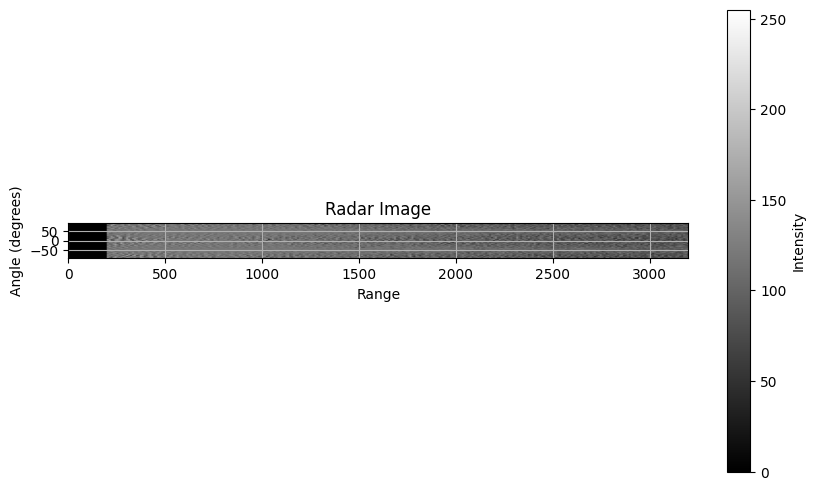

In [7]:
import matplotlib.pyplot as plt

# 可视化雷达图像
plt.figure(figsize=(10, 6))
plt.imshow(eta04[0], cmap='gray', origin='lower', extent=[0, 3200, -90, 90])
plt.colorbar(label='Intensity')
plt.title('Radar Image')
plt.xlabel('Range')
plt.ylabel('Angle (degrees)')
plt.grid(True)
plt.show()

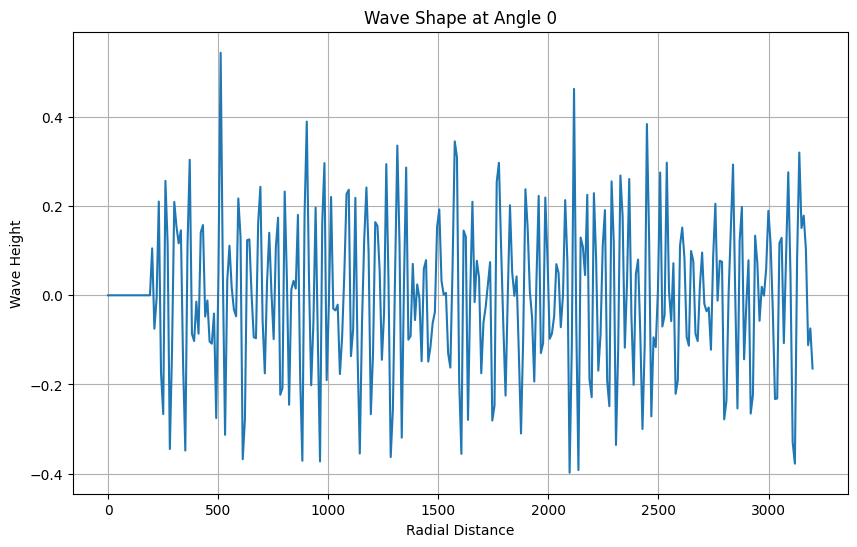

In [9]:
import matplotlib.pyplot as plt

# 选择第一帧数据和第一个角度
frame_index = 0
angle_index = 1
eta_frame = eta00[frame_index]
eta_angle = eta_frame[angle_index]

# 设置径向范围
r_values = np.linspace(0, 3200, 320)

# 可视化波浪形状
plt.figure(figsize=(10, 6))
plt.plot(r_values, eta_angle)
plt.title('Wave Shape at Angle 0')
plt.xlabel('Radial Distance')
plt.ylabel('Wave Height')
plt.grid(True)
plt.show()

In [10]:
import torch.nn as nn
import torch

In [12]:
hidden_prev = torch.zeros(1 , 1, 16)

In [13]:
print(hidden_prev)

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]])


In [34]:
data = np.array(eta00[:-1,1,:])



In [35]:
X = torch.tensor([data[i] for i in range(len(data) - 1)])  # 输入数据，不包含最后一个时间步的数据
Y = torch.tensor([data[i] for i in range(1, len(data))])   # 输出标签，不包含第一个时间步的数据

In [36]:
X.shape

torch.Size([30, 320])

In [39]:
batch_size = 1  # 假设每个批次的样本数量为1
seq_length = 30  # 每个样本的长度为32个时间步
input_size = 320  # 每个时间步有320个特征

X_tensor = X.view(batch_size, seq_length, input_size)
X_tensor.shape


torch.Size([1, 30, 320])